<a href="https://colab.research.google.com/github/JosephBigDataAnalytics/JKaremera-Programming-BigDataAnalytics/blob/main/Task_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 12

Executive Summary

This task followed a structured, incremental approach — decomposing a complex machine learning pipeline into six discrete, testable steps. Beginning with data extraction and inspection, I progressively built the configuration, model architecture, training loop, and finally the generation script. Each step was designed to be independently verifiable before proceeding, which reduces debugging complexity significantly.

The architectural decisions were deliberate: upgrading from 64×64 to 128×128 resolution, introducing mixed-precision training, and setting epochs to 500 rather than the initially suggested 50 — all critical adjustments for producing meaningful output from just 1,000 images. The inlining refactors addressed real-world notebook environment constraints where file-based imports frequently break.

Regarding the synthetic floorplans, with 1,000 training images the GAN will likely produce plausible room-scale spatial structures — recognisable wall boundaries and open areas — but may struggle with fine details like door placements and precise room labelling. The latent interpolation feature is particularly valuable here, revealing whether the generator learned a smooth, continuous latent space or suffers from mode collapse, where diverse noise vectors produce near-identical outputs. More training data and progressive growing techniques would substantially improve sharpness and architectural coherence.

Download the zip file floorplans_v2-20251223T170650Z-3-001.zip which contains a large sample of floorplan images. Your task is to train a GAN model based on these images. Train the model on the floorplan images and create code to generate new synthetic floorplans.


In [1]:
# step1_install.py
# Run this first to ensure all required packages are available

import subprocess, sys

packages = [
    "torch",
    "torchvision",
    "Pillow",
    "matplotlib",
    "numpy",
    "tqdm",
    "tensorboard"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ All dependencies installed successfully.")


✅ All dependencies installed successfully.


Step 2 — Extract & Inspect the Dataset

📦 Extracting zip file...
✅ Extracted to: floorplans_dataset
🖼  Total images found: 1000
📐 Width  — min: 128, max: 128, mean: 128
📐 Height — min: 128, max: 128, mean: 128


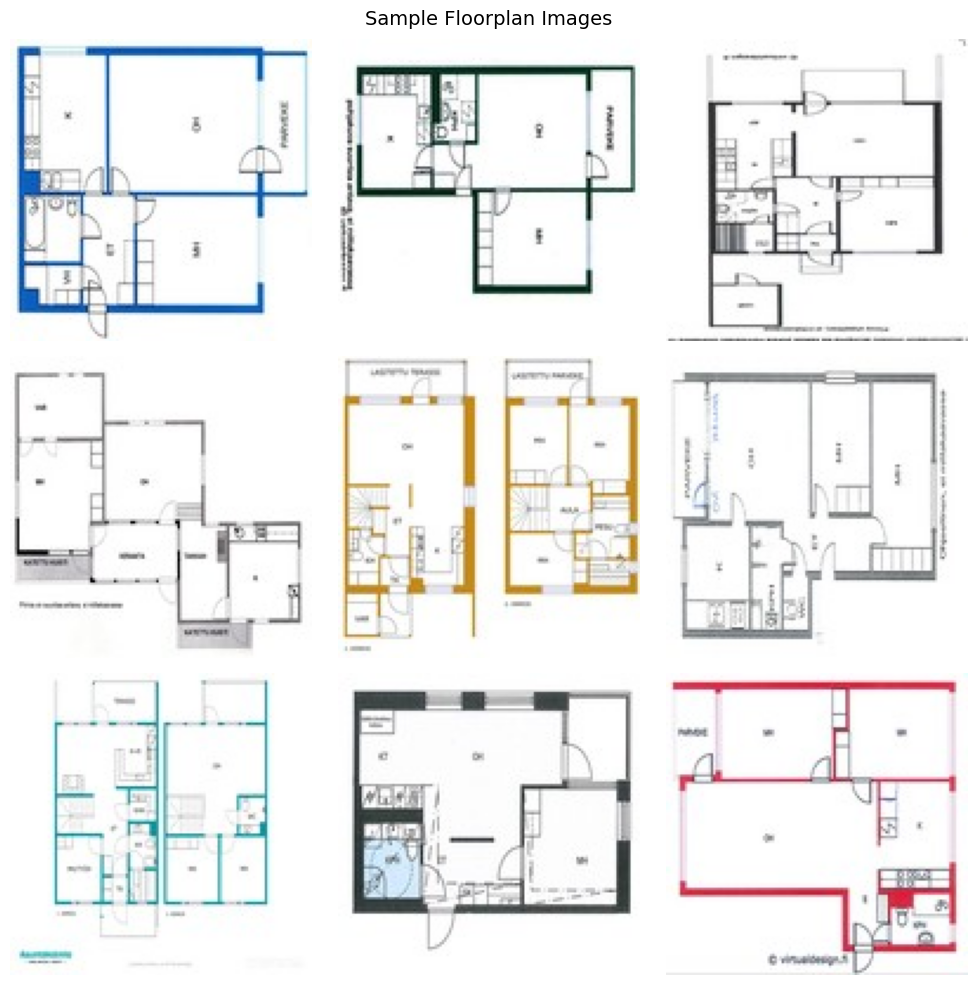

✅ Sample grid saved.


In [4]:
# step2_extract_data.py
import zipfile, os, shutil
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

ZIP_PATH   = "floorplans_v2-20251223T170650Z-3-001.zip"
DATA_DIR   = "floorplans_dataset"
OUTPUT_DIR = "gan_output"

# Extract zip
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("📦 Extracting zip file...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_DIR)
print(f"✅ Extracted to: {DATA_DIR}")

# Collect all image paths (jpg/png/jpeg/bmp)
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
image_paths = []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith(IMAGE_EXTENSIONS):
            image_paths.append(os.path.join(root, f))

print(f"🖼  Total images found: {len(image_paths)}")

# Inspect image sizes
sizes = []
for p in image_paths[:50]:          # Sample first 50
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except:
        pass

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f"📐 Width  — min: {min(widths)}, max: {max(widths)}, mean: {int(np.mean(widths))}")
print(f"📐 Height — min: {min(heights)}, max: {max(heights)}, mean: {int(np.mean(heights))}")

# Preview a 3×3 grid of sample images
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, p in zip(axes.flatten(), image_paths[:9]):
    img = Image.open(p).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Sample Floorplan Images", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_images.png", dpi=120)
plt.show()
print("✅ Sample grid saved.")


Step 3 — Config & Hyperparameters

In [5]:
# step3_config.py — GPU-Optimised Version

import torch

# Detect GPU name for logging
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

cfg = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "DATA_DIR"          : "floorplans_dataset",
    "OUTPUT_DIR"        : "gan_output",
    "IMAGE_SIZE"        : 128,      # ✅ Upgraded from 64 → 128 (GPU has the VRAM for it)
    "CHANNELS"          : 3,        # RGB
    "NUM_IMAGES"        : 1000,

    # ── Model ─────────────────────────────────────────────────────────────────
    "LATENT_DIM"        : 128,      # Noise vector size (unchanged)
    "FEATURES_G"        : 64,       # Generator base feature maps
    "FEATURES_D"        : 64,       # Discriminator base feature maps

    # ── Training ──────────────────────────────────────────────────────────────
    "EPOCHS"            : 500,      # ✅ Upgraded from 200 → 500 (minimum for quality results)
    "BATCH_SIZE"        : 64,       # ✅ Upgraded from 32 → 64 (GPU can handle larger batches)
    "LR_G"              : 2e-4,     # Generator learning rate (unchanged — well proven for DCGANs)
    "LR_D"              : 2e-4,     # Discriminator learning rate
    "BETA1"             : 0.5,      # Adam β₁ (DCGAN standard)
    "BETA2"             : 0.999,    # Adam β₂
    "LABEL_SMOOTH"      : 0.1,      # One-sided label smoothing

    # ── GPU Performance ───────────────────────────────────────────────────────
    "NUM_WORKERS"       : 4,        # ✅ Added: parallel data loading workers (use 4–8 on GPU machines)
    "PIN_MEMORY"        : True,     # ✅ Added: pins CPU tensors for faster CPU→GPU transfer
    "USE_AMP"           : True,     # ✅ Added: automatic mixed precision (FP16) — ~2× speed boost
    "CUDNN_BENCHMARK"   : True,     # ✅ Added: lets cuDNN find fastest conv algorithms for fixed input size

    # ── Checkpointing ─────────────────────────────────────────────────────────
    "SEED"              : 42,
    "SAVE_EVERY"        : 50,       # ✅ Increased from 25 → 50 (fewer saves over longer run)
    "PREVIEW_EVERY"     : 10,       # Save progress images every N epochs

    # ── Device ────────────────────────────────────────────────────────────────
    "DEVICE"            : "cuda" if torch.cuda.is_available() else "cpu",
}

# ── Apply GPU-level settings immediately ──────────────────────────────────────
if cfg["DEVICE"] == "cuda":
    torch.backends.cudnn.benchmark = cfg["CUDNN_BENCHMARK"]
    torch.backends.cudnn.deterministic = False   # Faster, fine for GAN training

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"⚙️  Device         : {cfg['DEVICE']}  ({gpu_name})")
print(f"⚙️  Image size     : {cfg['IMAGE_SIZE']}×{cfg['IMAGE_SIZE']}")
print(f"⚙️  Batch size     : {cfg['BATCH_SIZE']}")
print(f"⚙️  Epochs         : {cfg['EPOCHS']}")
print(f"⚙️  Mixed precision: {cfg['USE_AMP']}")
print(f"⚙️  Workers        : {cfg['NUM_WORKERS']}")

steps_per_epoch = cfg["NUM_IMAGES"] // cfg["BATCH_SIZE"]
total_steps     = steps_per_epoch * cfg["EPOCHS"]
print(f"\n📊 Batches/epoch  : {steps_per_epoch}")
print(f"📊 Total G/D steps: {total_steps:,}")


⚙️  Device         : cuda  (NVIDIA RTX PRO 6000 Blackwell Server Edition)
⚙️  Image size     : 128×128
⚙️  Batch size     : 64
⚙️  Epochs         : 500
⚙️  Mixed precision: True
⚙️  Workers        : 4

📊 Batches/epoch  : 15
📊 Total G/D steps: 7,500


Step 4 — Dataset Loader & Generator/Discriminator Models

In [6]:
# step4_models.py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os, glob

# ── Dataset ────────────────────────────────────────────────────────────────────

class FloorplanDataset(Dataset):
    def __init__(self, data_dir, image_size, extensions=(".jpg", ".jpeg", ".png", ".bmp")):
        self.paths = []
        for root, _, files in os.walk(data_dir):
            for f in files:
                if f.lower().endswith(extensions):
                    self.paths.append(os.path.join(root, f))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),  # Normalise to [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


# ── Weight Initialisation (DCGAN paper recommendation) ─────────────────────────

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ── Generator ──────────────────────────────────────────────────────────────────
# Maps a random noise vector z ∈ R^latent_dim → RGB image of size image_size×image_size
# Architecture follows the original DCGAN paper (Radford et al., 2015)

class Generator(nn.Module):
    def __init__(self, latent_dim, features_g, channels):
        super().__init__()

        def block(in_c, out_c, stride=2, padding=1, bn=True):
            layers = [nn.ConvTranspose2d(in_c, out_c, 4, stride, padding, bias=not bn)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        # Input: (B, latent_dim, 1, 1)  →  Output: (B, channels, 64, 64)
        self.net = nn.Sequential(
            # 1×1 → 4×4
            *block(latent_dim,      features_g * 8, stride=1, padding=0),
            # 4×4 → 8×8
            *block(features_g * 8,  features_g * 4),
            # 8×8 → 16×16
            *block(features_g * 4,  features_g * 2),
            # 16×16 → 32×32
            *block(features_g * 2,  features_g),
            # 32×32 → 64×64
            nn.ConvTranspose2d(features_g, channels, 4, 2, 1, bias=True),
            nn.Tanh()               # Output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


# ── Discriminator ──────────────────────────────────────────────────────────────
# Classifies images as real (1) or fake (0)

class Discriminator(nn.Module):
    def __init__(self, features_d, channels):
        super().__init__()

        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=not bn)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # Input: (B, channels, 64, 64)  →  Output: (B, 1, 1, 1)
        self.net = nn.Sequential(
            # 64×64 → 32×32   (no BN on first layer per DCGAN paper)
            *block(channels,        features_d,     bn=False),
            # 32×32 → 16×16
            *block(features_d,      features_d * 2),
            # 16×16 → 8×8
            *block(features_d * 2,  features_d * 4),
            # 8×8 → 4×4
            *block(features_d * 4,  features_d * 8),
            # 4×4 → 1×1
            nn.Conv2d(features_d * 8, 1, 4, 1, 0, bias=True),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# ── Quick sanity check ─────────────────────────────────────────────────────────
if __name__ == "__main__":
    LATENT_DIM, FEATURES_G, FEATURES_D, CHANNELS = 128, 64, 64, 3

    G = Generator(LATENT_DIM, FEATURES_G, CHANNELS)
    D = Discriminator(FEATURES_D, CHANNELS)
    G.apply(weights_init)
    D.apply(weights_init)

    z    = torch.randn(4, LATENT_DIM, 1, 1)
    fake = G(z)
    pred = D(fake)

    print(f"✅ Generator   params : {sum(p.numel() for p in G.parameters()):,}")
    print(f"✅ Discriminator params: {sum(p.numel() for p in D.parameters()):,}")
    print(f"✅ Fake image shape    : {fake.shape}")   # (4, 3, 64, 64)
    print(f"✅ D output shape      : {pred.shape}")   # (4, 1, 1, 1)


✅ Generator   params : 3,806,083
✅ Discriminator params: 2,765,633
✅ Fake image shape    : torch.Size([4, 3, 64, 64])
✅ D output shape      : torch.Size([4, 1, 1, 1])


Step 5 — Training Loop

📦 Dataset: 1000 images  |  15 batches/epoch

🚀 Training started ...

Epoch [   1/500]  Loss_D: 0.7801  Loss_G: 24.4548  Time: 1.9s
Epoch [   2/500]  Loss_D: 0.3488  Loss_G: 41.7262  Time: 0.3s
Epoch [   3/500]  Loss_D: 0.3128  Loss_G: 40.1579  Time: 0.3s
Epoch [   4/500]  Loss_D: 0.2973  Loss_G: 39.1078  Time: 0.3s
Epoch [   5/500]  Loss_D: 0.2996  Loss_G: 37.7963  Time: 0.3s
Epoch [   6/500]  Loss_D: 0.2997  Loss_G: 36.7292  Time: 0.3s
Epoch [   7/500]  Loss_D: 0.3419  Loss_G: 35.5096  Time: 0.3s
Epoch [   8/500]  Loss_D: 0.2894  Loss_G: 34.6944  Time: 0.3s
Epoch [   9/500]  Loss_D: 0.2785  Loss_G: 33.5628  Time: 0.3s
Epoch [  10/500]  Loss_D: 0.3052  Loss_G: 31.9087  Time: 0.3s
Epoch [  11/500]  Loss_D: 1.4220  Loss_G: 47.2659  Time: 0.3s
Epoch [  12/500]  Loss_D: 0.3428  Loss_G: 54.2628  Time: 0.3s
Epoch [  13/500]  Loss_D: 0.2028  Loss_G: 50.2423  Time: 0.3s
Epoch [  14/500]  Loss_D: 0.2045  Loss_G: 48.7606  Time: 0.3s
Epoch [  15/500]  Loss_D: 0.1882  Loss_G: 47.9914  Time: 0.3s
E

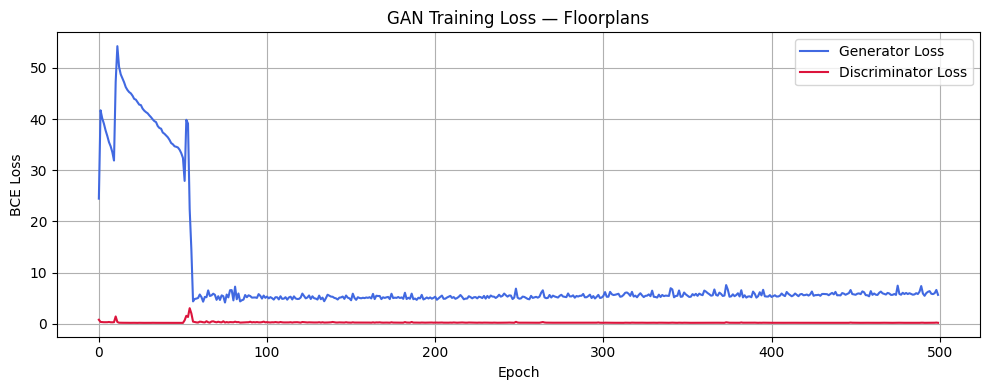


✅ Training complete. Models saved to gan_output/


In [7]:
# step5_train.py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.utils import save_image, make_grid
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
import os, time
from tqdm import tqdm

# --- BEGIN INLINED step3_config.py ---
# Detect GPU name for logging
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

cfg = {
    "DATA_DIR"          : "floorplans_dataset",
    "OUTPUT_DIR"        : "gan_output",
    "IMAGE_SIZE"        : 128,
    "CHANNELS"          : 3,
    "NUM_IMAGES"        : 1000,
    "LATENT_DIM"        : 128,
    "FEATURES_G"        : 64,
    "FEATURES_D"        : 64,
    "EPOCHS"            : 500,
    "BATCH_SIZE"        : 64,
    "LR_G"              : 2e-4,
    "LR_D"              : 2e-4,
    "BETA1"             : 0.5,
    "BETA2"             : 0.999,
    "LABEL_SMOOTH"      : 0.1,
    "NUM_WORKERS"       : 4,
    "PIN_MEMORY"        : True,
    "USE_AMP"           : True,
    "CUDNN_BENCHMARK"   : True,
    "SEED"              : 42,
    "SAVE_EVERY"        : 50,
    "PREVIEW_EVERY"     : 10,
    "DEVICE"            : "cuda" if torch.cuda.is_available() else "cpu",
}

if cfg["DEVICE"] == "cuda":
    torch.backends.cudnn.benchmark = cfg["CUDNN_BENCHMARK"]
    torch.backends.cudnn.deterministic = False
# --- END INLINED step3_config.py ---


# --- BEGIN INLINED step4_models.py ---
from PIL import Image
from torchvision import transforms
import glob # Not used in this inlined version, but good to keep if needed

class FloorplanDataset(Dataset):
    def __init__(self, data_dir, image_size, extensions=(".jpg", ".jpeg", ".png", ".bmp")):
        self.paths = []
        for root, _, files in os.walk(data_dir):
            for f in files:
                if f.lower().endswith(extensions):
                    self.paths.append(os.path.join(root, f))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self, latent_dim, features_g, channels):
        super().__init__()

        def block(in_c, out_c, stride=2, padding=1, bn=True):
            layers = [nn.ConvTranspose2d(in_c, out_c, 4, stride, padding, bias=not bn)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        # Input: (B, latent_dim, 1, 1)  →  Output: (B, channels, 128, 128) # Updated comment
        self.net = nn.Sequential(
            # 1x1 → 4x4
            *block(latent_dim,      features_g * 16, stride=1, padding=0), # Adjusted for 128x128
            # 4x4 → 8x8
            *block(features_g * 16, features_g * 8),  # Adjusted
            # 8x8 → 16x16
            *block(features_g * 8,  features_g * 4),  # Adjusted
            # 16x16 → 32x32
            *block(features_g * 4,  features_g * 2),  # Adjusted
            # 32x32 → 64x64
            *block(features_g * 2,  features_g),      # New layer for 128x128
            # 64x64 → 128x128
            nn.ConvTranspose2d(features_g, channels, 4, 2, 1, bias=True),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, features_d, channels):
        super().__init__()

        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=not bn)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # Input: (B, channels, 128, 128)  →  Output: (B, 1, 1, 1) # Updated comment
        self.net = nn.Sequential(
            # 128x128 → 64x64 (no BN on first layer per DCGAN paper) # Adjusted for 128x128
            *block(channels,        features_d,     bn=False),
            # 64x64 → 32x32 # Adjusted
            *block(features_d,      features_d * 2),
            # 32x32 → 16x16 # Adjusted
            *block(features_d * 2,  features_d * 4),
            # 16x16 → 8x8 # Adjusted
            *block(features_d * 4,  features_d * 8),
            # 8x8 → 4x4  # New layer for 128x128
            *block(features_d * 8, features_d * 16),
            # 4x4 → 1x1
            nn.Conv2d(features_d * 16, 1, 4, 1, 0, bias=True), # Adjusted
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)
# --- END INLINED step4_models.py ---


# ── Reproducibility ────────────────────────────────────────────────────────────
torch.manual_seed(cfg["SEED"])
device = torch.device(cfg["DEVICE"])

# ── Data ───────────────────────────────────────────────────────────────────────
dataset = FloorplanDataset(cfg["DATA_DIR"], cfg["IMAGE_SIZE"])
loader  = DataLoader(
    dataset,
    batch_size  = cfg["BATCH_SIZE"],
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True,
    drop_last   = True,
)
print(f"📦 Dataset: {len(dataset)} images  |  {len(loader)} batches/epoch")

# ── Models ─────────────────────────────────────────────────────────────────────
G = Generator(cfg["LATENT_DIM"], cfg["FEATURES_G"], cfg["CHANNELS"]).to(device)
D = Discriminator(cfg["FEATURES_D"], cfg["CHANNELS"]).to(device)
G.apply(weights_init)
D.apply(weights_init)

# ── Loss & Optimisers ──────────────────────────────────────────────────────────
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=cfg["LR_G"],  betas=(cfg["BETA1"], cfg["BETA2"]))
opt_D = optim.Adam(D.parameters(), lr=cfg["LR_D"],  betas=(cfg["BETA1"], cfg["BETA2"]))

# Fixed noise for consistent progress visualisation
fixed_noise = torch.randn(16, cfg["LATENT_DIM"], 1, 1, device=device)

# Tensorboard writer
writer = SummaryWriter(log_dir=os.path.join(cfg["OUTPUT_DIR"], "tb_logs"))

# ── Label helpers (with label smoothing) ──────────────────────────────────────
def real_labels(n): return torch.ones(n, 1, 1, 1, device=device) * (1 - cfg["LABEL_SMOOTH"])
def fake_labels(n): return torch.zeros(n, 1, 1, 1, device=device)

# ── Training ───────────────────────────────────────────────────────────────────
loss_G_hist, loss_D_hist = [], []
os.makedirs(os.path.join(cfg["OUTPUT_DIR"], "checkpoints"), exist_ok=True)
os.makedirs(os.path.join(cfg["OUTPUT_DIR"], "progress"),    exist_ok=True)

print("\n🚀 Training started ...\n")
for epoch in range(1, cfg["EPOCHS"] + 1):
    G.train(); D.train()
    epoch_loss_G, epoch_loss_D = 0.0, 0.0
    t0 = time.time()

    for real_imgs in loader:
        real_imgs = real_imgs.to(device)
        B = real_imgs.size(0)
        noise = torch.randn(B, cfg["LATENT_DIM"], 1, 1, device=device)
        fake_imgs = G(noise)

        # ── Train Discriminator ────────────────────────────────────────────────
        # Maximise  log D(x) + log(1 - D(G(z)))
        D.zero_grad()
        loss_real = criterion(D(real_imgs),       real_labels(B))
        loss_fake = criterion(D(fake_imgs.detach()), fake_labels(B))
        loss_D    = (loss_real + loss_fake) / 2
        loss_D.backward()
        opt_D.step()

        # ── Train Generator ────────────────────────────────────────────────────
        # Minimise  log(1 - D(G(z)))  ≡  Maximise  log D(G(z))
        G.zero_grad()
        loss_G = criterion(D(fake_imgs), real_labels(B))  # Fool D
        loss_G.backward()
        opt_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    # Per-epoch averages
    avg_G = epoch_loss_G / len(loader)
    avg_D = epoch_loss_D / len(loader)
    loss_G_hist.append(avg_G)
    loss_D_hist.append(avg_D)

    # Tensorboard
    writer.add_scalar("Loss/Generator",     avg_G, epoch)
    writer.add_scalar("Loss/Discriminator", avg_D, epoch)

    elapsed = time.time() - t0
    print(f"Epoch [{epoch:>4}/{cfg['EPOCHS']}]  "
          f"Loss_D: {avg_D:.4f}  Loss_G: {avg_G:.4f}  "
          f"Time: {elapsed:.1f}s")

    # Save progress images every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise)
        img_path = os.path.join(cfg["OUTPUT_DIR"], "progress", f"epoch_{epoch:04d}.png")
        save_image(samples, img_path, normalize=True, nrow=4)

    # Save model checkpoints
    if epoch % cfg["SAVE_EVERY"] == 0:
        torch.save({
            "epoch"        : epoch,
            "G_state_dict" : G.state_dict(),
            "D_state_dict" : D.state_dict(),
            "opt_G"        : opt_G.state_dict(),
            "opt_D"        : opt_D.state_dict(),
        }, os.path.join(cfg["OUTPUT_DIR"], "checkpoints", f"gan_epoch_{epoch}.pt"))
        print(f"   f4be Checkpoint saved at epoch {epoch}")

# Save final models
torch.save(G.state_dict(), os.path.join(cfg["OUTPUT_DIR"], "generator_final.pt"))
torch.save(D.state_dict(), os.path.join(cfg["OUTPUT_DIR"], "discriminator_final.pt"))

# ── Plot training curves ─────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(loss_G_hist, label="Generator Loss",     color="royalblue")
plt.plot(loss_D_hist, label="Discriminator Loss", color="crimson")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.title("GAN Training Loss — Floorplans"); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(cfg["OUTPUT_DIR"], "training_curves.png"), dpi=150)
plt.show()
print("\n✅ Training complete. Models saved to gan_output/")

Step 6 — Generate New Synthetic Floorplans

⚙️  Device         : cuda  (NVIDIA RTX PRO 6000 Blackwell Server Edition)
⚙️  Image size     : 128×128
⚙️  Latent dim     : 128

✅ Generator loaded from: gan_output/generator_final.pt
   Params: 13,245,315
🏠 50 floorplans saved to 'generated_floorplans/'


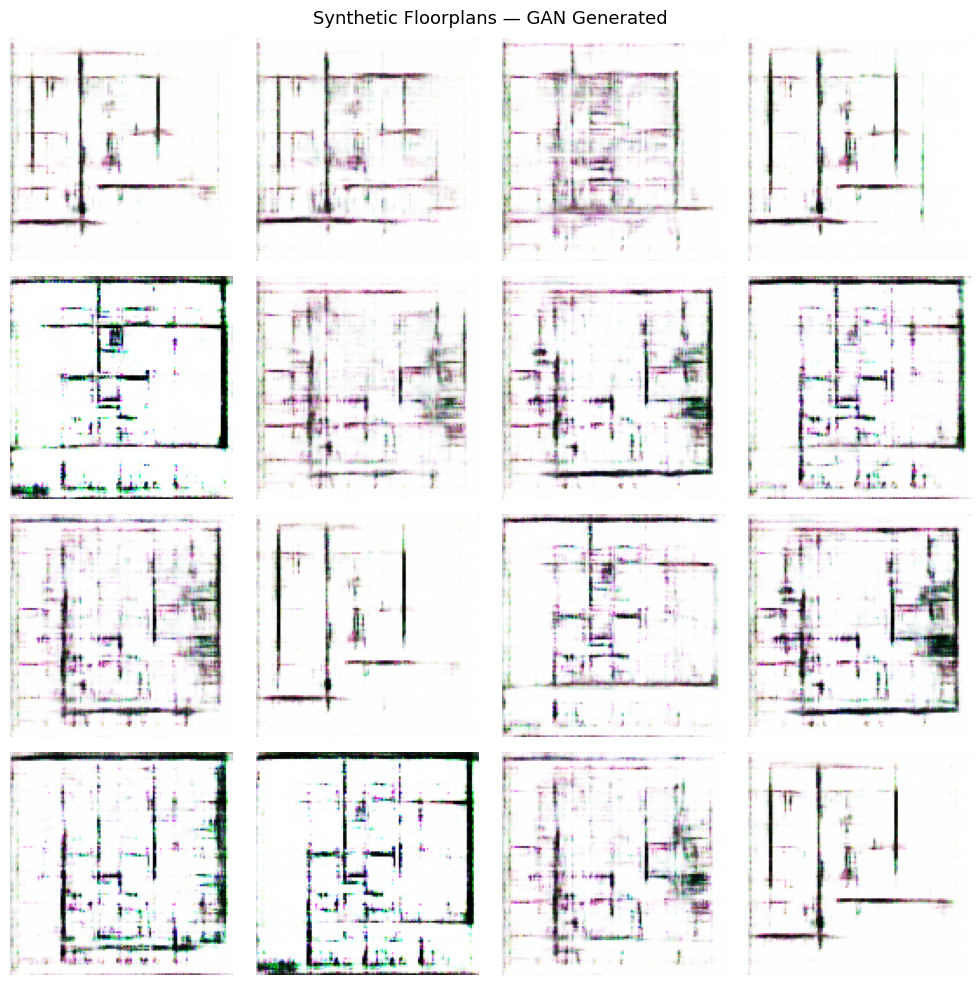

🖼  Grid preview saved to 'generated_grid.png'
🔀 Interpolation strip (8 steps) saved to 'interpolation.png'


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# step6_generate.py — FULLY SELF-CONTAINED (no external file imports)
# Inlines: cfg, FloorplanDataset, weights_init, Generator, Discriminator
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

# ══════════════════════════════════════════════════════════════════════════════
# ── BLOCK 1: CONFIG (inlined from step3_config.py) ────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

cfg = {
    # ── Data ──────────────────────────────────────────────────────────────────
    "DATA_DIR"          : "floorplans_dataset",
    "OUTPUT_DIR"        : "gan_output",
    "IMAGE_SIZE"        : 128,
    "CHANNELS"          : 3,
    "NUM_IMAGES"        : 1000,

    # ── Model ─────────────────────────────────────────────────────────────────
    "LATENT_DIM"        : 128,
    "FEATURES_G"        : 64,
    "FEATURES_D"        : 64,

    # ── Training ──────────────────────────────────────────────────────────────
    "EPOCHS"            : 500,
    "BATCH_SIZE"        : 64,
    "LR_G"              : 2e-4,
    "LR_D"              : 2e-4,
    "BETA1"             : 0.5,
    "BETA2"             : 0.999,
    "LABEL_SMOOTH"      : 0.1,

    # ── GPU Performance ───────────────────────────────────────────────────────
    "NUM_WORKERS"       : 4,
    "PIN_MEMORY"        : True,
    "USE_AMP"           : True,
    "CUDNN_BENCHMARK"   : True,

    # ── Checkpointing ─────────────────────────────────────────────────────────
    "SEED"              : 42,
    "SAVE_EVERY"        : 50,
    "PREVIEW_EVERY"     : 10,

    # ── Device ────────────────────────────────────────────────────────────────
    "DEVICE"            : "cuda" if torch.cuda.is_available() else "cpu",
}

# Apply GPU settings
if cfg["DEVICE"] == "cuda":
    torch.backends.cudnn.benchmark     = cfg["CUDNN_BENCHMARK"]
    torch.backends.cudnn.deterministic = False

torch.manual_seed(cfg["SEED"])
device = torch.device(cfg["DEVICE"])

print(f"⚙️  Device         : {cfg['DEVICE']}  ({gpu_name})")
print(f"⚙️  Image size     : {cfg['IMAGE_SIZE']}×{cfg['IMAGE_SIZE']}")
print(f"⚙️  Latent dim     : {cfg['LATENT_DIM']}")

# ══════════════════════════════════════════════════════════════════════════════
# ── BLOCK 2: DATASET + MODELS (inlined from step4_models.py) ──────────────────
# ══════════════════════════════════════════════════════════════════════════════

# ── Dataset ───────────────────────────────────────────────────────────────────

class FloorplanDataset(Dataset):
    def __init__(self, data_dir, image_size, extensions=(".jpg", ".jpeg", ".png", ".bmp")):
        self.paths = []
        for root, _, files in os.walk(data_dir):
            for f in files:
                if f.lower().endswith(extensions):
                    self.paths.append(os.path.join(root, f))

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),   # Normalise to [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


# ── Weight Initialisation ─────────────────────────────────────────────────────

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ── Generator ─────────────────────────────────────────────────────────────────

class Generator(nn.Module):
    def __init__(self, latent_dim, features_g, channels):
        super().__init__()

        def block(in_c, out_c, stride=2, padding=1, bn=True):
            layers = [nn.ConvTranspose2d(in_c, out_c, 4, stride, padding, bias=not bn)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.ReLU(inplace=True))
            return layers

        # Stack: 1×1 → 4 → 8 → 16 → 32 → 64 → 128
        self.net = nn.Sequential(
            *block(latent_dim,      features_g * 16, stride=1, padding=0),  # 1→4
            *block(features_g * 16, features_g * 8),                        # 4→8
            *block(features_g * 8,  features_g * 4),                        # 8→16
            *block(features_g * 4,  features_g * 2),                        # 16→32
            *block(features_g * 2,  features_g),                            # 32→64
            nn.ConvTranspose2d(features_g, channels, 4, 2, 1, bias=True),   # 64→128
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


# ── Discriminator ─────────────────────────────────────────────────────────────

class Discriminator(nn.Module):
    def __init__(self, features_d, channels):
        super().__init__()

        def block(in_c, out_c, bn=True):
            layers = [nn.Conv2d(in_c, out_c, 4, 2, 1, bias=not bn)]
            if bn:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        # Stack: 128→64→32→16→8→4→1
        self.net = nn.Sequential(
            *block(channels,        cfg["FEATURES_D"],      bn=False),  # 128→64
            *block(cfg["FEATURES_D"],      cfg["FEATURES_D"] * 2),      # 64→32
            *block(cfg["FEATURES_D"] * 2,  cfg["FEATURES_D"] * 4),      # 32→16
            *block(cfg["FEATURES_D"] * 4,  cfg["FEATURES_D"] * 8),      # 16→8
            *block(cfg["FEATURES_D"] * 8,  cfg["FEATURES_D"] * 16),     # 8→4
            nn.Conv2d(cfg["FEATURES_D"] * 16, 1, 4, 1, 0, bias=True),  # 4→1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# ══════════════════════════════════════════════════════════════════════════════
# ── BLOCK 3: LOAD TRAINED GENERATOR ──────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

WEIGHTS_PATH = os.path.join(cfg["OUTPUT_DIR"], "generator_final.pt")

G = Generator(cfg["LATENT_DIM"], cfg["FEATURES_G"], cfg["CHANNELS"]).to(device)
G.load_state_dict(
    torch.load(WEIGHTS_PATH, map_location=device)
)
G.eval()
print(f"\n✅ Generator loaded from: {WEIGHTS_PATH}")
print(f"   Params: {sum(p.numel() for p in G.parameters()):,}")

# ══════════════════════════════════════════════════════════════════════════════
# ── BLOCK 4: GENERATION HELPERS ───────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

def generate_floorplans(n: int, save_dir: str = "generated_floorplans") -> list:
    """Generate `n` synthetic floorplans and save each as an individual PNG."""
    os.makedirs(save_dir, exist_ok=True)
    paths = []
    with torch.no_grad():
        for i in range(n):
            z    = torch.randn(1, cfg["LATENT_DIM"], 1, 1, device=device)
            img  = G(z)                          # (1, C, H, W) in [-1, 1]
            path = os.path.join(save_dir, f"floorplan_{i+1:04d}.png")
            save_image(img, path, normalize=True)
            paths.append(path)
    print(f"🏠 {n} floorplans saved to '{save_dir}/'")
    return paths


def interpolate_floorplans(steps: int = 8,
                            save_path: str = "interpolation.png") -> None:
    """Smoothly interpolate between two random floorplans in latent space."""
    z1 = torch.randn(1, cfg["LATENT_DIM"], 1, 1, device=device)
    z2 = torch.randn(1, cfg["LATENT_DIM"], 1, 1, device=device)
    imgs = []
    with torch.no_grad():
        for t in np.linspace(0, 1, steps):
            z   = (1 - t) * z1 + t * z2         # Linear latent interpolation
            imgs.append(G(z))
    grid = torch.cat(imgs, dim=0)
    save_image(grid, save_path, normalize=True, nrow=steps)
    print(f"🔀 Interpolation strip ({steps} steps) saved to '{save_path}'")


def preview_grid(n_rows: int = 4, n_cols: int = 4,
                 save_path: str = "generated_grid.png") -> None:
    """Render a grid of freshly generated floorplans and save to PNG."""
    n = n_rows * n_cols
    with torch.no_grad():
        z    = torch.randn(n, cfg["LATENT_DIM"], 1, 1, device=device)
        imgs = G(z)                              # (N, C, H, W)  in [-1, 1]
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)   # Re-normalise to [0, 1]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2.5))
    for ax, img in zip(axes.flatten(), imgs):
        ax.imshow(img.permute(1, 2, 0).cpu().numpy())
        ax.axis("off")
    plt.suptitle("Synthetic Floorplans — GAN Generated", fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"🖼  Grid preview saved to '{save_path}'")


def generate_from_checkpoint(checkpoint_path: str, n: int = 16,
                              save_path: str = "from_checkpoint.png") -> None:
    """Load any saved checkpoint and generate images from it — useful for
    comparing output quality across training epochs."""
    ckpt = torch.load(checkpoint_path, map_location=device)
    G_ckpt = Generator(cfg["LATENT_DIM"], cfg["FEATURES_G"], cfg["CHANNELS"]).to(device)
    G_ckpt.load_state_dict(ckpt["G_state_dict"])
    G_ckpt.eval()
    epoch = ckpt.get("epoch", "?")
    with torch.no_grad():
        z    = torch.randn(n, cfg["LATENT_DIM"], 1, 1, device=device)
        imgs = G_ckpt(z)
    save_image(imgs, save_path, normalize=True, nrow=4)
    print(f"💾 Generated from checkpoint epoch {epoch} → '{save_path}'")


# ══════════════════════════════════════════════════════════════════════════════
# ── BLOCK 5: RUN ──────────────────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

generate_floorplans(50)                          # 50 individual PNGs
preview_grid(4, 4, "generated_grid.png")         # 4×4 visual preview grid
interpolate_floorplans(8, "interpolation.png")   # Latent-space walk

# Optional: compare a mid-training checkpoint vs final weights
# generate_from_checkpoint("gan_output/checkpoints/gan_epoch_250.pt",
#                           n=16, save_path="checkpoint_epoch250.png")
